# **Bài thực hành 7. Xác định mối quan hệ giữa các biến**

Võ Bạch Kim Thịnh - 2045230096

## **7.1. Mô tả tập dữ liệu**

PM2_5: Nồng độ bụi mịn PM2.5

PM10: Nồng độ bụi PM10

NO2: Nồng độ khí NO2

CO: Nồng độ khí CO

TrafficLevel: Mức độ giao thông (1–10)

IndustrialActivity: Mức độ công nghiệp (1–10)

GreenSpaceIndex: Tỷ lệ cây xanh (%)

PublicTransportUsage: Tỷ lệ dùng phương tiện công cộng (%)

AirQualityIndex: Biến mục tiêu (AQI)

CityZone: Khu vực (Residential, Commercial, Industrial, Suburban)

WeatherCondition: Thời tiết

**Nhiệm vụ**
* Xác định biến nào liên quan đến AQI
* Phát hiện biến “có vẻ liên quan nhưng thực tế không”

## **7.2. Load dữ liệu**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('environment_data.csv')

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PM2_5                 2000 non-null   float64
 1   PM10                  2000 non-null   float64
 2   NO2                   2000 non-null   float64
 3   CO                    2000 non-null   float64
 4   TrafficLevel          2000 non-null   int64  
 5   IndustrialActivity    2000 non-null   int64  
 6   CityZone              2000 non-null   object 
 7   WeatherCondition      2000 non-null   object 
 8   GreenSpaceIndex       2000 non-null   float64
 9   PublicTransportUsage  2000 non-null   float64
 10  AirQualityIndex       2000 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 172.0+ KB
None


,PM2_5,PM10,NO2,CO,TrafficLevel,IndustrialActivity,CityZone,WeatherCondition,GreenSpaceIndex,PublicTransportUsage,AirQualityIndex
0,39.967142,49.872326,18.092051,0.865776,6,7,Residential,Windy,44.292590,97.330708,107.642359
1,33.617357,57.832220,24.750372,1.010721,8,5,Suburban,Windy,36.508346,99.038418,104.846588
2,41.476885,48.113701,25.144135,0.917382,7,9,Commercial,Sunny,58.642096,65.017813,91.185041
3,50.230299,55.380577,28.781043,1.035601,5,4,Commercial,Cloudy,67.231618,12.711929,92.611146
4,32.658466,31.595780,14.065133,1.135755,4,1,Commercial,Rainy,48.097480,50.617009,61.585728


* **Có bao nhiêu biến?** Tập dữ liệu có 11 biến (cột).
* **Theo bạn, biến nào ảnh hưởng mạnh nhất đến AQI?** Dự đoán ban đầu là các biến về lượng khí thải/bụi như PM2.5, PM10 hoặc Mức độ công nghiệp (IndustrialActivity) sẽ ảnh hưởng mạnh nhất.
* **Biến nào là numerical?** PM2_5, PM10, NO2, CO, TrafficLevel, IndustrialActivity, GreenSpaceIndex, PublicTransportUsage, AirQualityIndex (9 biến).
* **Biến nào là categorical?** CityZone, WeatherCondition (2 biến).
* **Vì sao cần phân biệt hai loại biến này?** Để lựa chọn phương pháp phân tích thống kê và vẽ biểu đồ phù hợp. (Ví dụ: biến numerical dùng hệ số tương quan Pearson, biến categorical dùng ANOVA/Chi-square).

### **TRỰC QUAN HÓA**

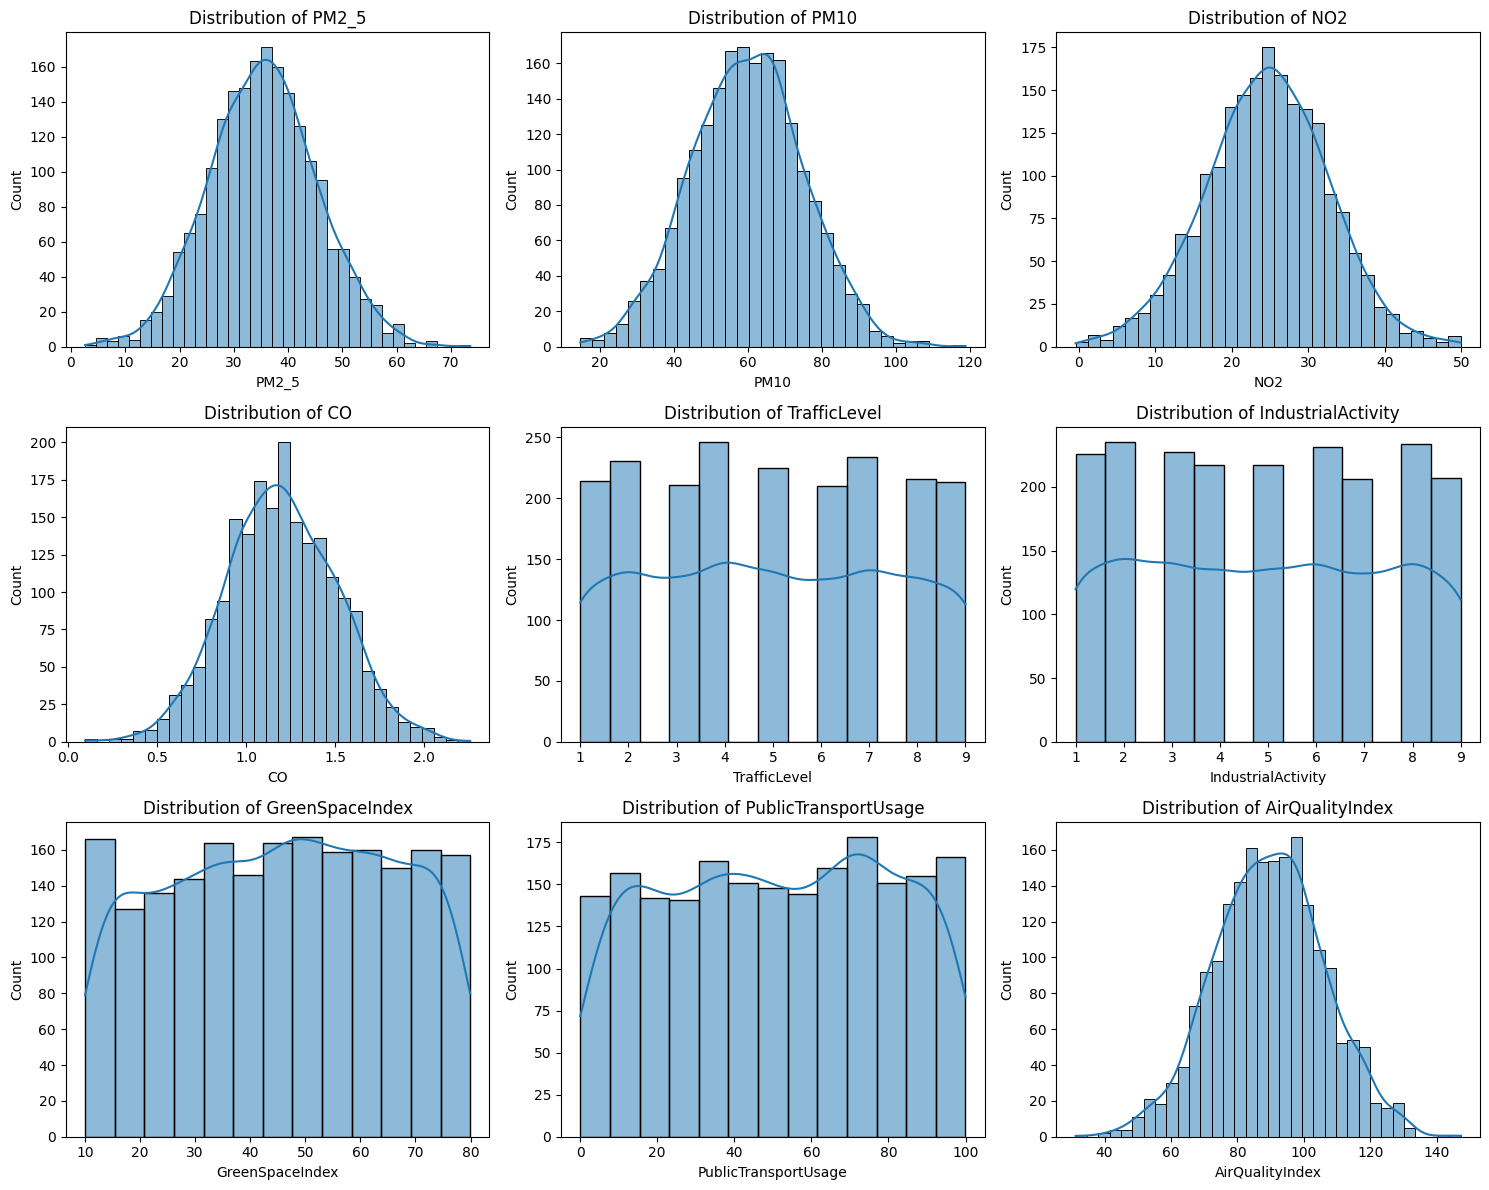

In [ ]:
numerical_cols = ['PM2_5', 'PM10', 'NO2', 'CO', 'TrafficLevel', 'IndustrialActivity', 'GreenSpaceIndex', 'PublicTransportUsage', 'AirQualityIndex']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_33029/402502364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_33029/402502364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


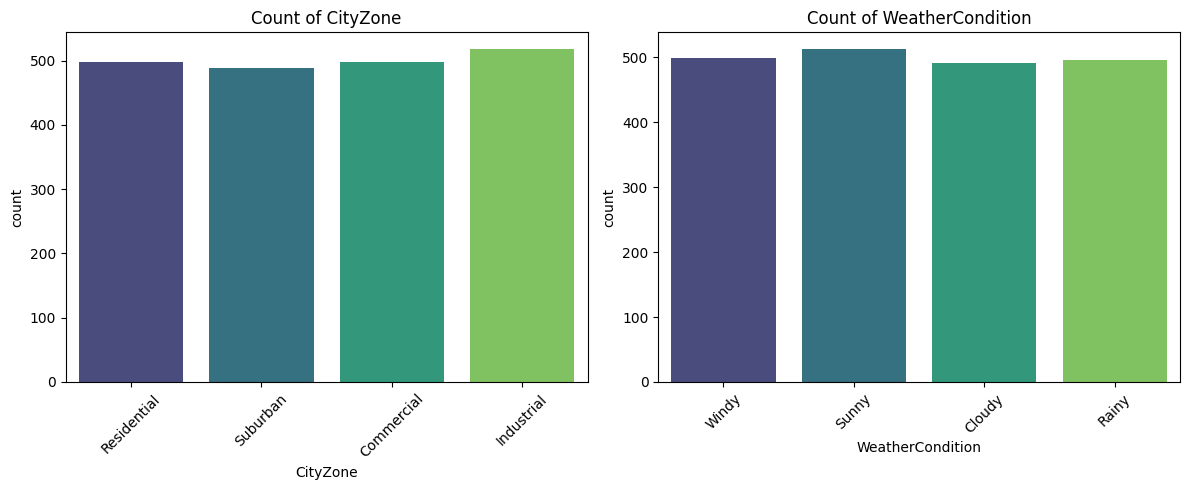

In [ ]:
categorical_cols = ['CityZone', 'WeatherCondition']

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **7.3. Tương quan Pearson**

Tương quan với AQI:
AirQualityIndex         1.000000
IndustrialActivity      0.452277
PM2_5                   0.368941
PM10                    0.349257
TrafficLevel            0.328405
CO                      0.150015
NO2                     0.139095
PublicTransportUsage    0.023637
GreenSpaceIndex         0.001802
Name: AirQualityIndex, dtype: float64


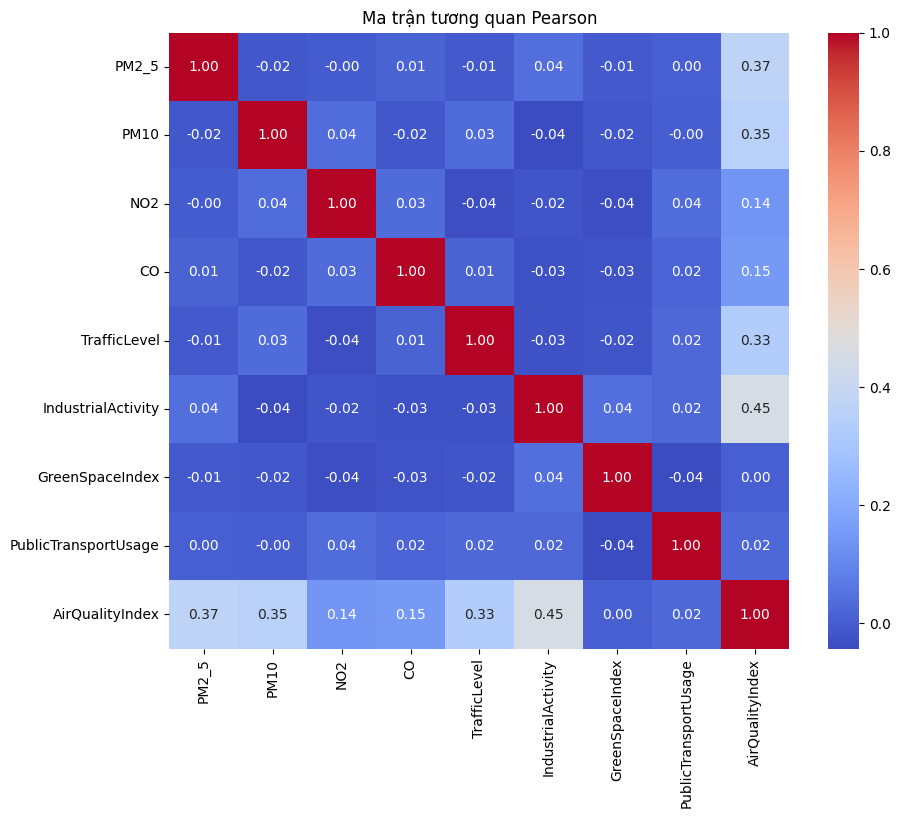

In [ ]:
correlation = df.corr(numeric_only=True)

print("Tương quan với AQI:")
print(correlation['AirQualityIndex'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan Pearson")
plt.show()

* **Biến nào có tương quan cao nhất với AQI?** `IndustrialActivity` có tương quan cao nhất (0.45), tiếp theo là `PM2_5` (0.37) và `PM10` (0.35).

* **Biến nào gần như không tương quan?** `GreenSpaceIndex` (0.0018) và `PublicTransportUsage` (0.024) gần như không có tương quan.
* **Có nhóm biến nào tương quan mạnh với nhau không?** Các biến liên quan đến mức độ ô nhiễm (IndustrialActivity, TrafficLevel, PM2_5, PM10) thường có xu hướng đi cùng nhau (tương quan dương).
* **Có dấu hiệu “nhiễu” không?** Có. Thông thường tỷ lệ cây xanh (`GreenSpaceIndex`) và giao thông công cộng (`PublicTransportUsage`) phải có tương quan âm (giúp giảm AQI), nhưng ở đây chúng xấp xỉ 0. Đây là những biến nhiễu hoặc "gây hiểu lầm" trong bộ dữ liệu này.

## **7.4. ANOVA**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
model_city = ols('AirQualityIndex ~ C(CityZone)', data=df).fit()
anova_city = sm.stats.anova_lm(model_city, typ=2)
print("--- ANOVA: CityZone ---")
print(anova_city)

model_weather = ols('AirQualityIndex ~ C(WeatherCondition)', data=df).fit()
anova_weather = sm.stats.anova_lm(model_weather, typ=2)
print("\n--- ANOVA: WeatherCondition ---")
print(anova_weather)

--- ANOVA: CityZone ---
                    sum_sq      df         F    PR(>F)
C(CityZone)    1901.480464     3.0  2.342942  0.071319
Residual     539969.970658  1996.0       NaN       NaN

--- ANOVA: WeatherCondition ---
                            sum_sq      df         F    PR(>F)
C(WeatherCondition)     818.870205     3.0  1.006966  0.388648
Residual             541052.580916  1996.0       NaN       NaN


* **CityZone có ảnh hưởng đến AQI không?** P-value của CityZone là ~0.071 (> 0.05). Do đó, về mặt thống kê, chưa đủ cơ sở để khẳng định CityZone làm thay đổi đáng kể AQI trong tập dữ liệu này.
* **Điều này có hợp lý với thực tế không?** Khá bất ngờ so với thực tế (thường khu công nghiệp sẽ ô nhiễm hơn khu dân cư). Có thể do ô nhiễm trong thành phố này lan truyền đồng đều, hoặc thiết kế lấy mẫu dữ liệu có đặc thù riêng.
* **Thời tiết có ảnh hưởng đến AQI không?** P-value của WeatherCondition là ~0.389 (> 0.05). Vậy điều kiện thời tiết không có tác động đáng kể đến sự thay đổi của AQI.

## **7.5. Chi-square**

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['CityZone'], df['WeatherCondition'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-square ---")
print("p-value:", p)

--- Chi-square ---
p-value: 0.6531588998823841


* **CityZone có liên quan đến WeatherCondition không?** P-value ~0.653 (> 0.05). Điều này cho thấy khu vực (`CityZone`) và thời tiết (`WeatherCondition`) hoàn toàn độc lập, không có liên hệ với nhau.
* **Điều này có ảnh hưởng gián tiếp đến AQI không?** Vì hai biến này độc lập và bản thân chúng ở phần ANOVA cũng không ảnh hưởng mạnh lên AQI, nên không có tác động gián tiếp nào đáng kể lên chất lượng không khí.

## **7.6. Tổng hợp kết quả**

* **Biến thực sự liên quan mạnh đến AQI:** `IndustrialActivity` (Mức độ công nghiệp), `PM2_5`, `PM10` và `TrafficLevel` (Mức độ giao thông).
* **Biến không có ảnh hưởng rõ ràng:** `CityZone` (Khu vực) và `WeatherCondition` (Thời tiết) không tạo ra sự khác biệt về mặt thống kê.
* **Biến gây hiểu lầm:** `GreenSpaceIndex` và `PublicTransportUsage`. Dù theo lý thuyết chúng giúp giảm ô nhiễm, nhưng trong dữ liệu này, chúng không có tương quan (hệ số gần 0) và không hề đóng góp vào việc cải thiện AQI.

--------------------------------------------------------------------------------

## **7.7. Phân tích dữ liệu môi trường đại dương và xác định yếu tố ảnh hưởng**

Mục tiêu của bài thực hành này là phân tích bộ dữ liệu `ocean_environment_data.csv` để đánh giá tình trạng sức khỏe môi trường biển và tìm ra các nguyên nhân (yếu tố) tác động trực tiếp đến nó.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency

In [ ]:
df_ocean = pd.read_csv('ocean_environment_data.csv')
df_ocean.head()

,TourismIndex,pHLevel,OceanRegion,DissolvedOxygen,ShippingTraffic,FishingIntensity,WaterTemperature,ResearchStationNearby,NitrateLevel,CoralReefPresence,CoastalDevelopmentIndex,PollutionSource,MarineHealthStatus
0,55.543698,7.972872,Pacific,4.982258,224.570578,High,22.483571,Yes,2.827892,Yes,86.272996,NaN,Moderate
1,60.357135,7.963976,Pacific,5.541751,413.766244,High,19.308678,Yes,2.960813,Yes,32.337362,Industrial,Moderate
2,34.600165,7.561307,Atlantic,5.103928,106.411243,Low,23.238443,Yes,3.077154,Yes,8.032830,Agricultural,Moderate
3,1.874116,8.000973,Indian,6.165627,207.163215,Low,27.615149,Yes,4.136234,No,2.726748,Industrial,Polluted
4,2.161472,8.319849,Arctic,7.795768,263.883946,Medium,18.829233,No,2.103339,Yes,11.000096,NaN,Healthy


In [ ]:
# 1. Xem thông tin các biến
print("--- THÔNG TIN DỮ LIỆU ---")
df_ocean.info()

# 2. Thống kê mô tả các biến định lượng
print("\n--- THỐNG KÊ MÔ TẢ ---")
display(df_ocean.describe())

# 3. Phân bố biến mục tiêu
print("\n--- PHÂN BỐ BIẾN MỤC TIÊU (MarineHealthStatus) ---")
print(df_ocean['MarineHealthStatus'].value_counts())

--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TourismIndex             5000 non-null   float64
 1   pHLevel                  5000 non-null   float64
 2   OceanRegion              5000 non-null   object 
 3   DissolvedOxygen          5000 non-null   float64
 4   ShippingTraffic          5000 non-null   float64
 5   FishingIntensity         5000 non-null   object 
 6   WaterTemperature         5000 non-null   float64
 7   ResearchStationNearby    5000 non-null   object 
 8   NitrateLevel             5000 non-null   float64
 9   CoralReefPresence        5000 non-null   object 
 10  CoastalDevelopmentIndex  5000 non-null   float64
 11  PollutionSource          3810 non-null   object 
 12  MarineHealthStatus       5000 non-null   object 
dtypes: float64(7), object(6)
memory usage: 507.9+ KB

--

,TourismIndex,pHLevel,DissolvedOxygen,ShippingTraffic,WaterTemperature,NitrateLevel,CoastalDevelopmentIndex
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,49.702161,8.097038,6.015830,249.863398,20.028010,3.019818,49.563757
std,28.832586,0.303131,1.498155,144.933731,4.982399,1.204004,29.086599
min,0.009757,6.923280,0.936631,0.008368,3.793663,-1.627650,0.009359
25%,24.735243,7.894025,5.008670,125.333407,16.710475,2.202383,23.936214
50%,49.857722,8.094765,6.014876,247.848208,20.067328,3.023111,49.078686
75%,74.581696,8.303171,7.013301,377.674567,23.330053,3.847938,75.263209
max,99.978937,9.158717,11.143366,499.986074,39.631189,8.374901,99.995695



--- PHÂN BỐ BIẾN MỤC TIÊU (MarineHealthStatus) ---
MarineHealthStatus
Moderate    2336
Healthy     1727
Polluted     937
Name: count, dtype: int64


* **Xác định loại của từng biến:**
  * **Biến định lượng (Numerical - 7 biến):** `TourismIndex`, `pHLevel`, `DissolvedOxygen`, `ShippingTraffic`, `WaterTemperature`, `NitrateLevel`, `CoastalDevelopmentIndex`.
  * **Biến phân loại (Categorical - 6 biến):** `OceanRegion`, `FishingIntensity`, `ResearchStationNearby`, `CoralReefPresence`, `PollutionSource` và biến mục tiêu `MarineHealthStatus`.
* **Thống kê mô tả:** Tập dữ liệu có 5.000 dòng. Hầu hết các biến đều đầy đủ dữ liệu, riêng cột `PollutionSource` chỉ có 3.810 giá trị (có dòng bị khuyết hoặc không có nguồn ô nhiễm). Các chỉ số trải rộng ở nhiều khu vực đại dương.
* **Phân bố của biến mục tiêu:** * Moderate (Trung bình): 2.336
  * Healthy (Khỏe mạnh): 1.727
  * Polluted (Ô nhiễm): 937
  * *Nhận xét:* Dữ liệu tập trung nhiều nhất ở mức Trung bình, và ít nhất ở mức Ô nhiễm.

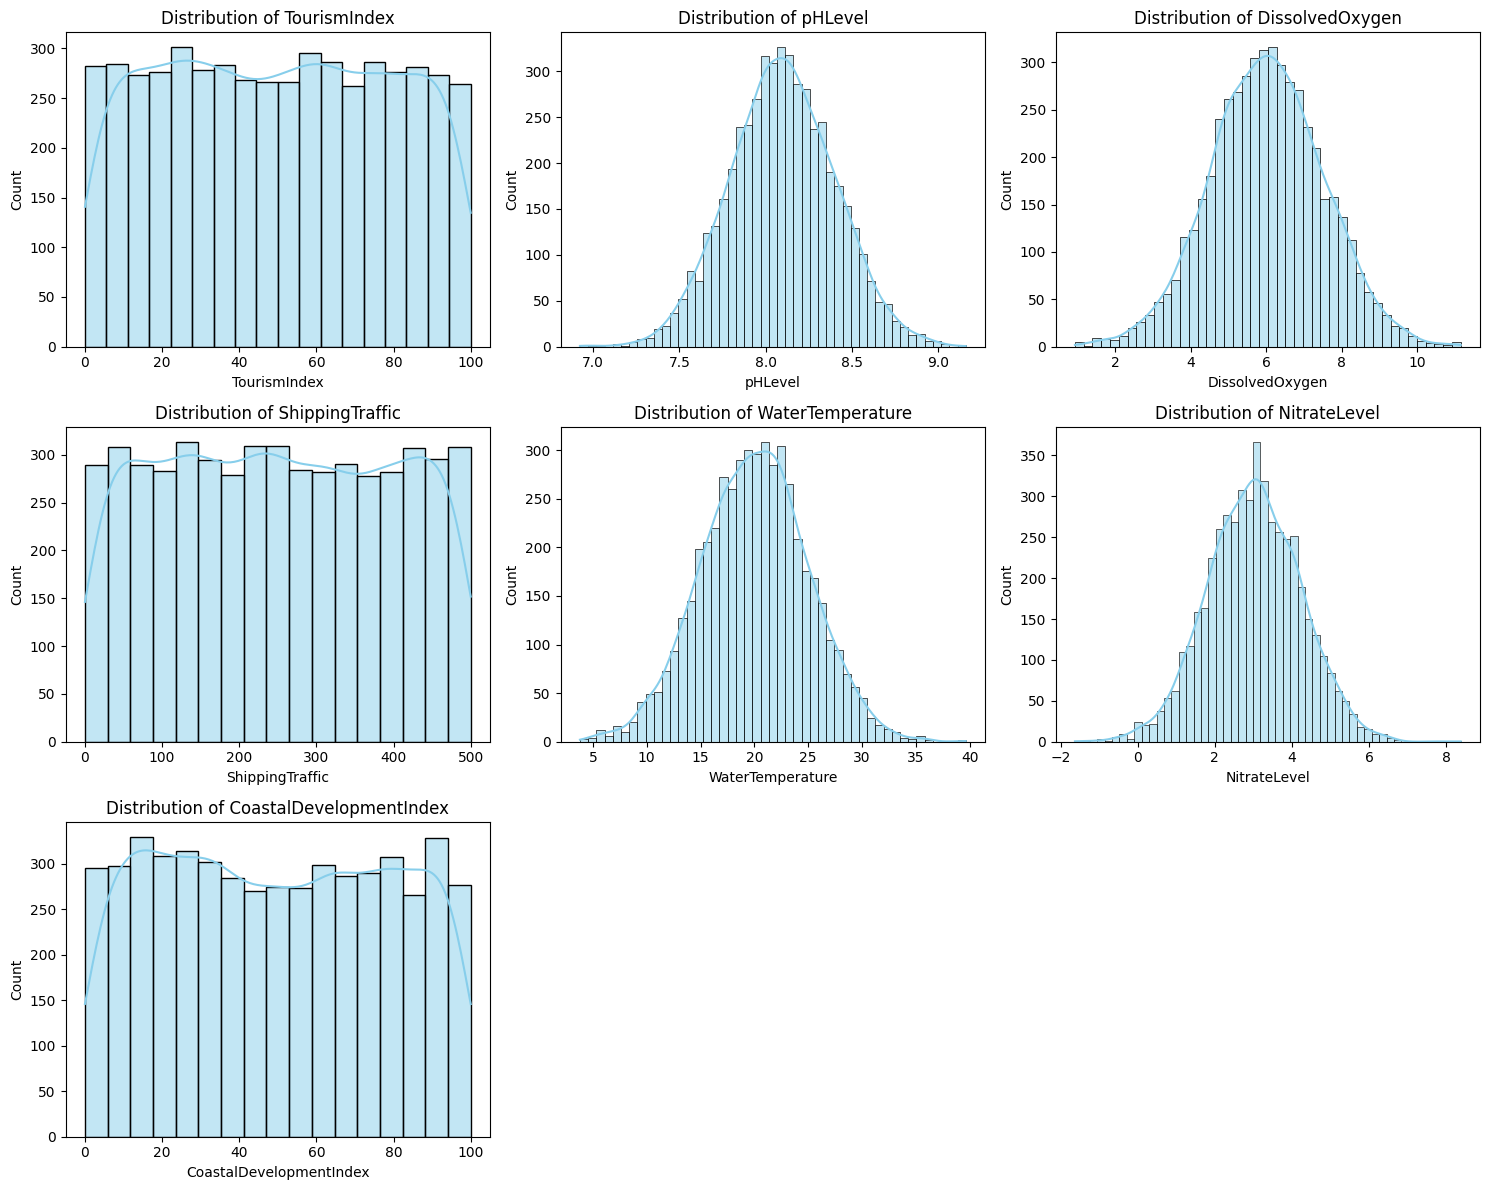

In [ ]:
# Trực quan hóa các biến numerical
numeric_cols_ocean = df_ocean.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols_ocean, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_ocean[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_33029/14818262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ocean, x=col, palette='viridis')
/tmp/ipykernel_33029/14818262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ocean, x=col, palette='viridis')
/tmp/ipykernel_33029/14818262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ocean, x=col, palette='viridis')
/tmp/ipykernel_33029/14818262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

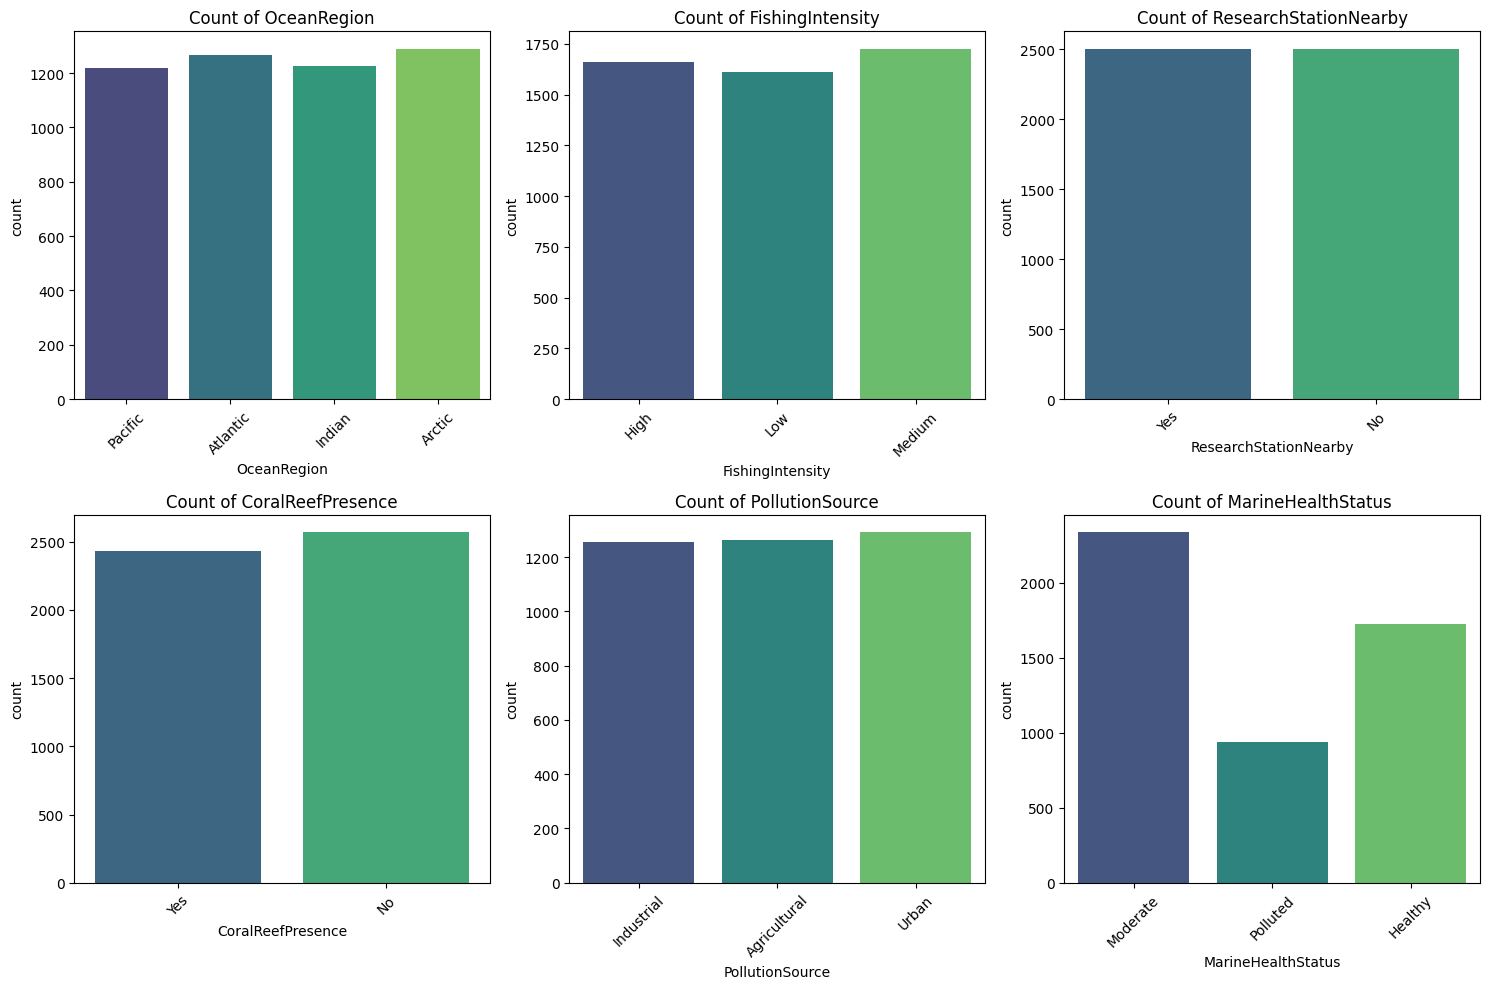

In [ ]:
# Trực quan hóa các biến categorical
cat_cols_ocean = df_ocean.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols_ocean, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df_ocean, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

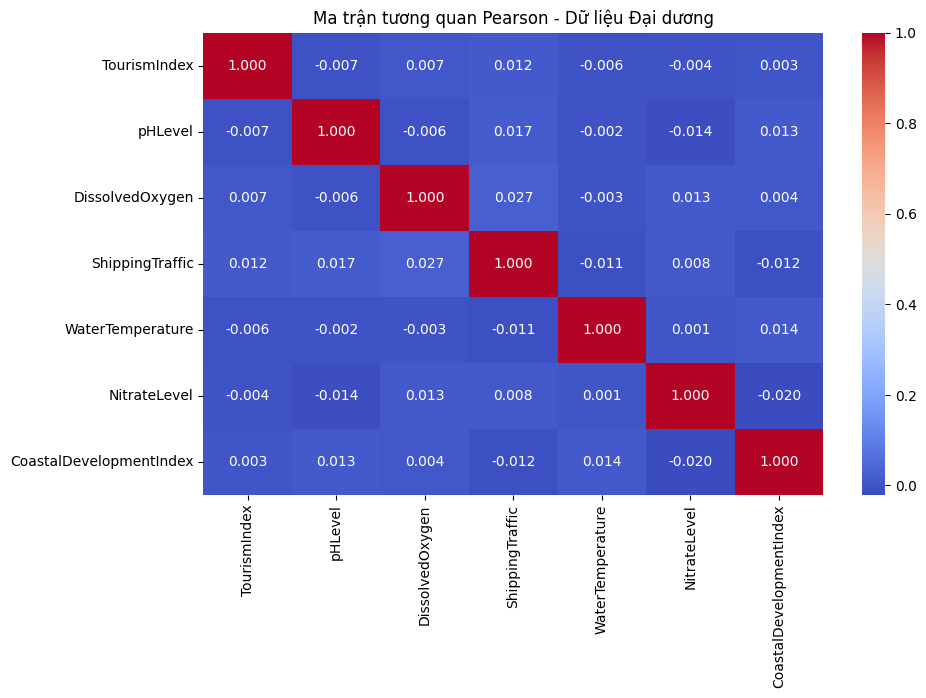


--- KIỂM ĐỊNH ANOVA ---
TourismIndex: p-value = 0.1862
pHLevel: p-value = 0.8627
DissolvedOxygen: p-value = 0.0000
ShippingTraffic: p-value = 0.4941
WaterTemperature: p-value = 0.0000
NitrateLevel: p-value = 0.0000
CoastalDevelopmentIndex: p-value = 0.4550

--- KIỂM ĐỊNH CHI-SQUARE ---
OceanRegion: p-value = 0.3021
FishingIntensity: p-value = 0.0000
ResearchStationNearby: p-value = 0.5688
CoralReefPresence: p-value = 0.0000
PollutionSource: p-value = 0.0000


In [ ]:
# 1. Tương quan Pearson (Biến định lượng vs Biến định lượng)
corr = df_ocean.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Ma trận tương quan Pearson - Dữ liệu Đại dương")
plt.show()

# 2. ANOVA (Biến định lượng vs Biến mục tiêu phân loại)
print("\n--- KIỂM ĐỊNH ANOVA ---")
numeric_cols = df_ocean.select_dtypes(include='number').columns
for col in numeric_cols:
    model = ols(f'{col} ~ C(MarineHealthStatus)', data=df_ocean).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    p_val = anova['PR(>F)']['C(MarineHealthStatus)']
    print(f"{col}: p-value = {p_val:.4f}")

# 3. Chi-square (Biến phân loại vs Biến mục tiêu phân loại)
print("\n--- KIỂM ĐỊNH CHI-SQUARE ---")
cat_cols = df_ocean.select_dtypes(include=['object']).columns.drop('MarineHealthStatus')
for col in cat_cols:
    contingency = pd.crosstab(df_ocean[col], df_ocean['MarineHealthStatus'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: p-value = {p:.4f}")

* **Mối quan hệ giữa các biến định lượng với nhau:** Dựa vào biểu đồ Heatmap, hệ số tương quan giữa tất cả các cặp biến định lượng đều rất gần 0 (cao nhất chỉ ~0.027). Điều này cho thấy các biến định lượng trong tập dữ liệu này hoàn toàn độc lập với nhau.
* **Mối liên hệ giữa các biến định lượng và biến mục tiêu (ANOVA):** * Các biến có **p-value = 0.0000** (< 0.05) bao gồm: `DissolvedOxygen`, `WaterTemperature`, `NitrateLevel`. Chúng có sự khác biệt rõ rệt theo từng nhóm trạng thái biển.
  * Các biến có **p-value > 0.05**: `TourismIndex`, `pHLevel`, `ShippingTraffic`, `CoastalDevelopmentIndex` không có sự khác biệt thống kê giữa các mức độ sức khỏe môi trường biển.
* **Mối liên hệ giữa các biến phân loại và biến mục tiêu (Chi-square):**
  * Các biến có **p-value = 0.0000** (< 0.05) bao gồm: `FishingIntensity`, `CoralReefPresence`, `PollutionSource`. Chúng có liên quan mật thiết đến trạng thái biển.
  * Các biến có **p-value > 0.05**: `OceanRegion` và `ResearchStationNearby` hoàn toàn độc lập với trạng thái biển.

Từ các kết quả phân tích thống kê phía trên với `df_ocean`, ta có thể kết luận:

1. **Các biến có ảnh hưởng mạnh đến tình trạng môi trường biển:**
   * **Nhóm hóa/lý sinh:** Nồng độ oxy hòa tan (`DissolvedOxygen`), Nhiệt độ nước (`WaterTemperature`), Nồng độ nitrate (`NitrateLevel`).
   * **Nhóm sinh học/con người:** Sự hiện diện rạn san hô (`CoralReefPresence`), Mức độ khai thác thủy sản (`FishingIntensity`), và Nguồn ô nhiễm (`PollutionSource`).

2. **Các biến không có ảnh hưởng rõ ràng:**
   * Mật độ tàu thuyền (`ShippingTraffic`), Phát triển ven biển (`CoastalDevelopmentIndex`), Du lịch (`TourismIndex`), Khu vực (`OceanRegion`), Độ pH (`pHLevel`) và Trạm nghiên cứu (`ResearchStationNearby`).

3. **So sánh với nhận định ban đầu:**
   * *Điểm hợp lý:* Oxy hòa tan, Nitrate, hóa chất công nghiệp và việc đánh bắt cá ảnh hưởng mạnh đến môi trường là điều hoàn toàn phù hợp với kiến thức sinh thái học thực tế.
   * *Điểm bất ngờ gây "hiểu lầm":* Rất nhiều người sẽ cho rằng mật độ tàu thuyền cao (`ShippingTraffic`), phát triển ven biển (`CoastalDevelopmentIndex`) hay chỉ số du lịch (`TourismIndex`) sẽ trực tiếp làm biển bị ô nhiễm. Tuy nhiên, dữ liệu `df_ocean` lại chứng minh chúng không có ảnh hưởng thống kê rõ rệt. Tương tự, độ pH (`pHLevel`) thường được dùng để đo axit hóa đại dương nhưng lại không đóng vai trò phân biệt mức độ ô nhiễm ở tập dữ liệu cụ thể này. Qua đó cho thấy, phân tích khoa học dữ liệu giúp ta nhìn nhận lại và loại bỏ những định kiến chủ quan chưa được kiểm chứng.